Programming Exercise: Optimal circle placement

Task 1: Basic analysis of the problem
Solve the following questions (in paper or markdown format inside a Jupyter notebook).
• How many decision variables do we have in this problem?
    - 3n decision variables - x,y,r. Center and Radius for each of the n circles.
• How many constraints do we have in this problem?
    - nC2 + 5n decision constraints
• What type of problem is this?
    - Objective functions is Quadratic
    - No Equality constraints
    - Inequality constraints are quadratic
    - So, it is a QCQP (Quadratic Constrained Quadratic programming) problem
• Is it convex?
    - Depends on n.
    - It is convex if n is even, and not when n is odd.

Task 2: Implementation and solution of the problem

Implement the problem as described above, solve it using CasADi and IPOPT, as in the previous exercises,
and visualize the solution.
For the visualization part, you can use the Python file plotting circles.py provided together with
this exercise.

Parametrize number of circles N and side length of square A

In [9]:
#Initializing Number of Circles
N = 5
#Initializing side length of the square
a = 10

Below is the code to optimize the basic (unmodified) task - fitting circles inside squares to maximize the area occupied

In [88]:
import casadi as ca

opti = ca.Opti()

#Variable Definitions
Centers = opti.variable(N, 2)
R = opti.variable(N)

#Defining Objective
f = 0
for i in range(N):
    f += -ca.pi*R[i]**2

opti.minimize(f)

#Constraints
for i in range(N):
    opti.subject_to(R[i] >= 0)
    opti.subject_to(Centers[i, 0] + R[i] <= a)
    opti.subject_to(Centers[i, 0] >= R[i])
    opti.subject_to(Centers[i, 1] + R[i] <= a)
    opti.subject_to(Centers[i, 1] >= R[i])
    for j in range(i):
        opti.subject_to((Centers[i, 0] - Centers[j, 0])**2 + (Centers[i, 1] - Centers[j, 1])**2 >= (R[i] + R[j])**2)

opti.solver("ipopt")
#Set an initial Guess for R[0]
opti.set_initial(R[0], 2.5)
opti.set_initial(Centers[4, 0], 10)
opti.set_initial(Centers[3, 0], 10)
sol = opti.solve()


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:      105
Number of nonzeros in Lagrangian Hessian.............:       45

Total number of variables............................:       15
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       35
        inequality constraints with only lower bounds:        5
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       30

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.9634954e+01 6.25e+00 1.11e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

Visualize the solution obtained (sol) using plot_solution method defined in visualization_circles.py

Radii of the N circles -  [5.00000005 0.85786438 0.42893219 0.14718625 0.85786438]
Centers of the N circles -  [[5.00000005 5.00000005]
 [0.85786438 0.85786438]
 [0.42893218 2.07106782]
 [9.85281384 0.14718625]
 [9.14213571 0.85786438]]
Optimized Value -  -83.80986870809875


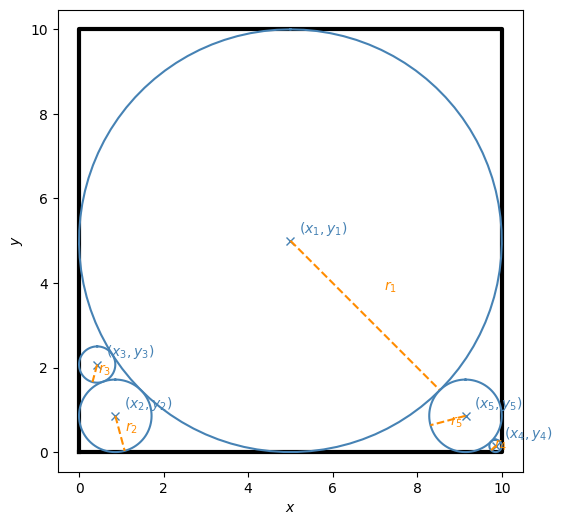

In [89]:
from visualization_circles import plot_circle, plot_solution 

r = sol.value(R)
centers = sol.value(Centers)
f_min = sol.value(f)
print ("Radii of the N circles - ", r)
print ("Centers of the N circles - ", centers)
print ("Optimized Value - ", f_min)

plot_solution(centers, r, a, 'Task2_visualization.png')


Task 3: Implement some modification/extension to the problem

Implement two of the four following possible modifications/extensions to the problem. For each modification, implement the task and explain how you modified the optimization problem to solve it (in paper or Markdown format within a Jupyter notebook). Then, interpret the results you obtained, and compare them to the original problem.

Task 3.1 - Instead of maximizing the covered area, maximize the minimum radius of the circles. You might
also make a trade-off between the two objectives.

To acheive this, we're gonna constrain R[0] such that it holds the minimum radius of all, and add additional constrains to make sure that it is the minimum. Modified objective is (for min) is -R[0]

In [72]:

#Optimizer for Task 3.1

opti_3_1 = ca.Opti()

#Variable Definitions
Centers_3_1 = opti_3_1.variable(N, 2)
R_3_1 = opti_3_1.variable(N)

# #Defining Objective
# f_3_1 = 0
# for i in range(N):
#     f_3_1 += -ca.pi*R_3_1[i]**2
#Defining Modified Objective
f_3_1 = -1*R_3_1[0]

opti_3_1.minimize(f_3_1)

#Constraints
for i in range(N):
    opti_3_1.subject_to(R_3_1[i] >= 0)
    opti_3_1.subject_to(Centers_3_1[i, 0] + R_3_1[i] <= a)
    opti_3_1.subject_to(Centers_3_1[i, 0] >= R_3_1[i])
    opti_3_1.subject_to(Centers_3_1[i, 1] + R_3_1[i] <= a)
    opti_3_1.subject_to(Centers_3_1[i, 1] >= R_3_1[i])
    for j in range(i):
        opti_3_1.subject_to((Centers_3_1[i, 0] - Centers_3_1[j, 0])**2 + (Centers_3_1[i, 1] - Centers_3_1[j, 1])**2 >= (R_3_1[i] + R_3_1[j])**2)
    #Adding additional constraints
    if i>0:
        opti_3_1.subject_to(R_3_1[0] <= R_3_1[i])

opti_3_1.solver("ipopt")

#Set initial Guess for R[0]
#opti_3_1.set_initial(R_3_1[0], 0)
opti_3_1.set_initial(R_3_1[0], 5)
#opti_3_1.set_initial(R_3_1[0], 4)

sol_3_1 = opti_3_1.solve()


    

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:      113
Number of nonzeros in Lagrangian Hessian.............:       45

Total number of variables............................:       15
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       39
        inequality constraints with only lower bounds:        5
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       34

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -5.0000000e+00 2.50e+01 1.15e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

Print and visualize the optimal setup

Radii of the N circles -  [1.96438265 1.96438265 1.96438265 1.96438266 1.96438265]
Centers of the N circles -  [[8.03561742 5.25756082]
 [1.96438269 5.89314808]
 [5.25756082 8.03561742]
 [1.96438271 1.96438271]
 [5.89314809 1.96438269]]
Optimized Value -  -1.964382649917182


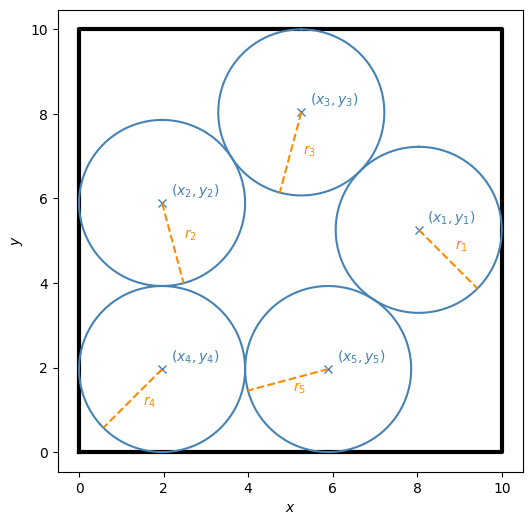

In [73]:
r_3_1 = sol_3_1.value(R_3_1)
centers_3_1 = sol_3_1.value(Centers_3_1)
f_min_3_1 = sol_3_1.value(f_3_1)
print ("Radii of the N circles - ", r_3_1)
print ("Centers of the N circles - ", centers_3_1)
print ("Optimized Value - ", f_min_3_1)

plot_solution(centers_3_1, r_3_1, a, 'Task2_visualization.png')

Task 3.2 - Change the shape of the objects: instead of the circles in a square, place some squares in a circle or
in a rectangle.



Task 3.3 - Study the behavior of the solution when the number of circles/squares increases, and plot the optimal
value with respect to the number of circles/squares. What do you observe, and how do you interpret
this behavior?

Task 3.4 - Find at least two different local minima of the problem, and compare their optimal values. You
might do so by changing the initial guess.

With no initial Guesses - Optima - 81.5
Forcing 2 of the Centers to extremes along X - 83.8

Task 4: Create your own modification to the problem - by changing both the objective and the constraints of the problem. Atleast 2 changes